# What Drives the Price of a Used Car?

**Practical Application 2: Used Car Pricing**

This notebook follows the CRISP-DM framework to identify the vehicle attributes most associated with used-car prices. The client is a used-car dealership that wants practical guidance on inventory and pricing decisions.


## Business Understanding

The business question is: **what do consumers appear to value in a used car, and how can a dealership use those signals to fine-tune inventory and pricing?**

I translate that into a data problem as follows: build regression models that predict listed vehicle price from vehicle attributes, then interpret the strongest price drivers in business language. The target variable is `price`; the predictor variables include vehicle age, mileage, manufacturer, vehicle type, condition, title status, fuel type, transmission, drive type, color, and geography.

A useful model is not only accurate; it also needs to produce recommendations a dealership can act on. I therefore evaluate the models with dollar-based error metrics and inspect feature effects after modeling.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid")
    HAS_SEABORN = True
except Exception:
    HAS_SEABORN = False
    plt.style.use("ggplot")

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")


In [2]:
vehicles = pd.read_csv("data/vehicles.csv")
vehicles.shape


(426880, 18)

In [3]:
vehicles.head()


,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
0,7222695916,prescott,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az
1,7218891961,fayetteville,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar
2,7221797935,florida keys,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl
3,7222270760,worcester / central MA,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma
4,7210384030,greensboro,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc


## Data Understanding

The raw dataset contains **426,880 rows** and **18 columns**. It includes listing-level attributes such as manufacturer, model, year, odometer reading, condition, fuel type, title status, transmission, drive, vehicle type, paint color, state, and price.

The initial data-quality review shows three major issues:

- `price` contains impossible or extreme values, including zero-dollar listings and very large outliers.
- Several descriptive columns have substantial missingness, especially `size`, `cylinders`, `condition`, `VIN`, `drive`, `paint_color`, and `type`.
- Identifier fields such as `id` and `VIN` should not be used as price drivers because they identify listings rather than generalizable consumer preferences.


In [4]:
vehicles.info()


<class 'pandas.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   region        426880 non-null  str    
 2   price         426880 non-null  int64  
 3   year          425675 non-null  float64
 4   manufacturer  409234 non-null  str    
 5   model         421603 non-null  str    
 6   condition     252776 non-null  str    
 7   cylinders     249202 non-null  str    
 8   fuel          423867 non-null  str    
 9   odometer      422480 non-null  float64
 10  title_status  418638 non-null  str    
 11  transmission  424324 non-null  str    
 12  VIN           265838 non-null  str    
 13  drive         296313 non-null  str    
 14  size          120519 non-null  str    
 15  type          334022 non-null  str    
 16  paint_color   296677 non-null  str    
 17  state         426880 non-null  str    
dtypes: float64(2), 

In [5]:
missing = (
    vehicles.isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .rename("missing_percent")
    .reset_index()
    .rename(columns={"index": "column"})
)
missing


,column,missing_percent
0,size,71.77
1,cylinders,41.62
2,condition,40.79
3,VIN,37.73
4,drive,30.59
5,paint_color,30.50
6,type,21.75
7,manufacturer,4.13
8,title_status,1.93
9,model,1.24


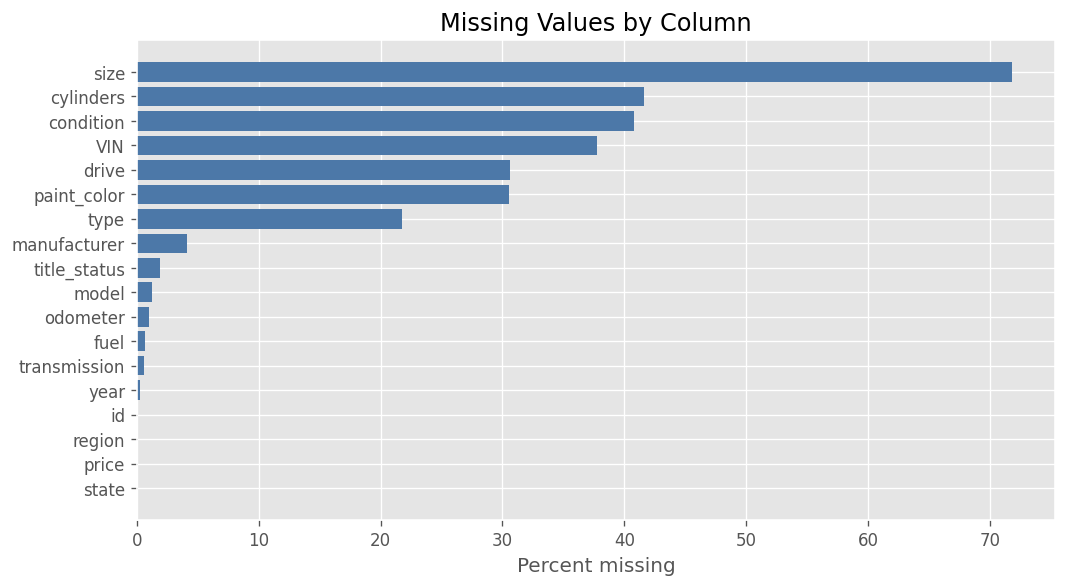

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(missing["column"], missing["missing_percent"], color="#4c78a8")
ax.invert_yaxis()
ax.set_title("Missing Values by Column")
ax.set_xlabel("Percent missing")
ax.set_ylabel("")
plt.tight_layout()
plt.show()


In [7]:
vehicles[["price", "year", "odometer"]].describe()


,price,year,odometer
count,"426,880.00","425,675.00","422,480.00"
mean,"75,199.03","2,011.24","98,043.33"
std,"12,182,282.17",9.45,"213,881.50"
min,0.00,"1,900.00",0.00
25%,"5,900.00","2,008.00","37,704.00"
50%,"13,950.00","2,013.00","85,548.00"
75%,"26,485.75","2,017.00","133,542.50"
max,"3,736,928,711.00","2,022.00","10,000,000.00"


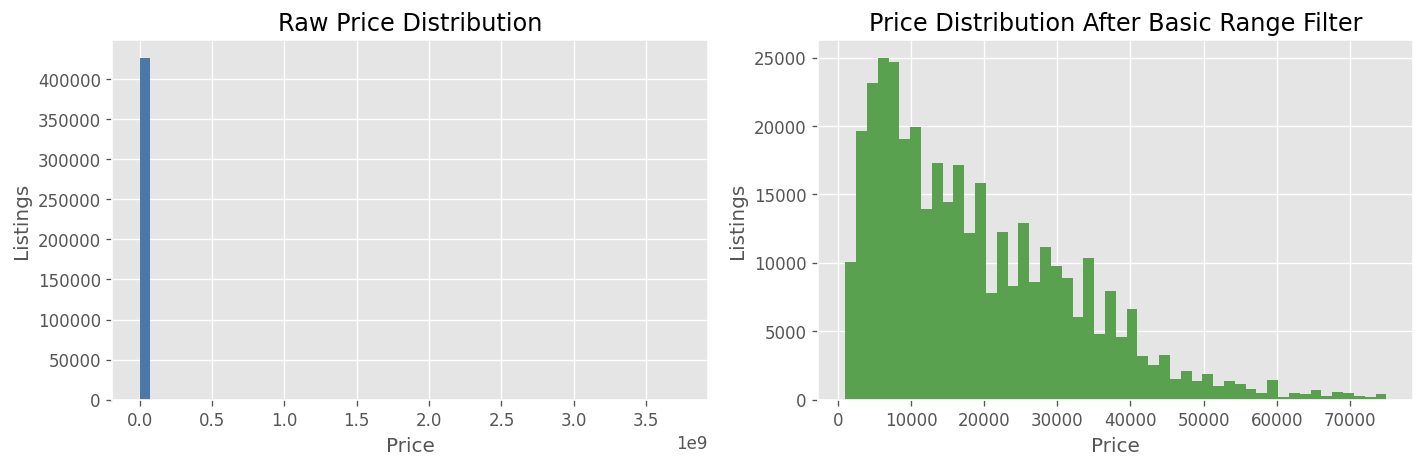

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(vehicles["price"], bins=50, color="#4c78a8")
axes[0].set_title("Raw Price Distribution")
axes[0].set_xlabel("Price")
axes[0].set_ylabel("Listings")

reasonable_prices = vehicles.loc[vehicles["price"].between(1000, 75000), "price"]
axes[1].hist(reasonable_prices, bins=50, color="#59a14f")
axes[1].set_title("Price Distribution After Basic Range Filter")
axes[1].set_xlabel("Price")
axes[1].set_ylabel("Listings")
plt.tight_layout()
plt.show()


## Data Preparation

I use conservative cleaning rules to remove records that would distort model training:

- Keep listings with `1000 <= price <= 75000`.
- Keep vehicles from model years 1990-2022.
- Keep odometer readings from 1,000-250,000 miles.
- Drop rows missing key modeling fields: year, odometer, manufacturer, fuel, title status, or transmission.
- Fill missing optional categorical fields with `"unknown"` so the model can learn whether missing listing detail is itself informative.
- Create `car_age = 2022 - year`.
- Model `log_price` to reduce the influence of remaining price skew.

These rules leave a large working sample while removing values that are likely data-entry artifacts rather than meaningful dealership signals.


In [9]:
def clean_vehicle_data(df):
    cleaned = df.copy()
    cleaned = cleaned[
        cleaned["price"].between(1000, 75000)
        & cleaned["year"].between(1990, 2022)
        & cleaned["odometer"].between(1000, 250000)
    ].copy()
    cleaned = cleaned.dropna(
        subset=["year", "odometer", "manufacturer", "fuel", "title_status", "transmission"]
    )
    cleaned["car_age"] = 2022 - cleaned["year"]
    cleaned["log_price"] = np.log1p(cleaned["price"])

    categorical_cols = [
        "region", "manufacturer", "condition", "cylinders", "fuel",
        "title_status", "transmission", "drive", "size", "type",
        "paint_color", "state"
    ]
    for col in categorical_cols:
        cleaned[col] = cleaned[col].fillna("unknown").astype(str).str.lower()
    return cleaned

cars = clean_vehicle_data(vehicles)
cars.shape


(333327, 20)

In [10]:
print(f"Rows kept after cleaning: {len(cars):,} ({len(cars) / len(vehicles):.1%} of raw data)")
cars[["price", "year", "car_age", "odometer"]].describe()


Rows kept after cleaning: 333,327 (78.1% of raw data)


,price,year,car_age,odometer
count,"333,327.00","333,327.00","333,327.00","333,327.00"
mean,"19,320.36","2,012.43",9.57,"92,450.19"
std,"13,574.95",5.67,5.67,"58,730.31"
min,"1,000.00","1,990.00",0.00,"1,000.00"
25%,"7,995.00","2,009.00",5.00,"40,338.00"
50%,"16,067.00","2,014.00",8.00,"89,000.00"
75%,"27,990.00","2,017.00",13.00,"135,298.00"
max,"75,000.00","2,022.00",32.00,"250,000.00"


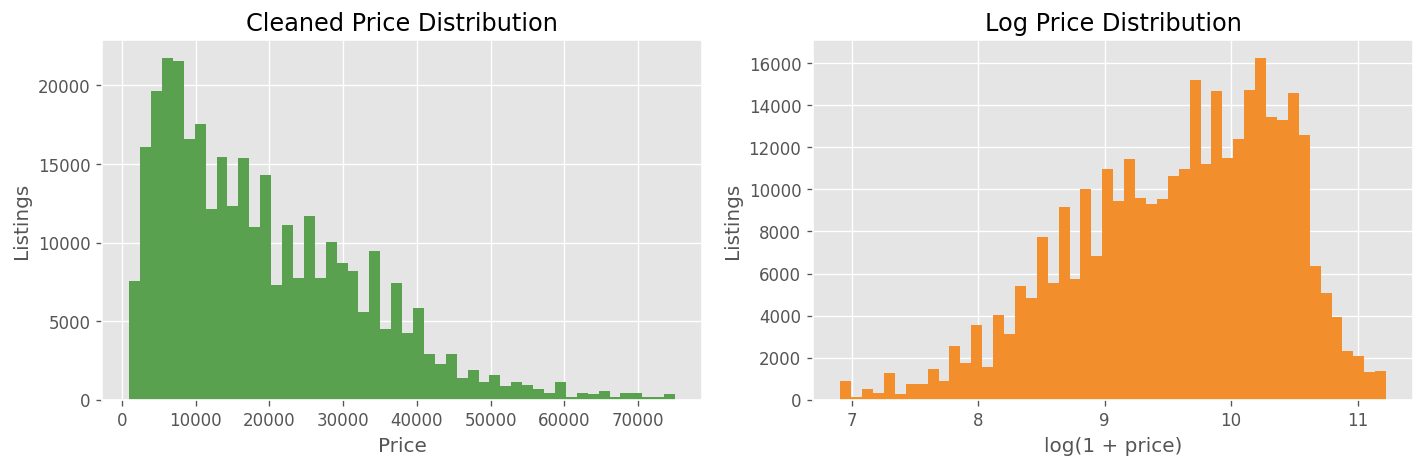

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(cars["price"], bins=50, color="#59a14f")
axes[0].set_title("Cleaned Price Distribution")
axes[0].set_xlabel("Price")
axes[0].set_ylabel("Listings")

axes[1].hist(cars["log_price"], bins=50, color="#f28e2b")
axes[1].set_title("Log Price Distribution")
axes[1].set_xlabel("log(1 + price)")
axes[1].set_ylabel("Listings")
plt.tight_layout()
plt.show()


After cleaning, the modeling dataset contains **333,327 listings**, or about **78.1%** of the raw dataset. This is still a large dataset for identifying broad pricing patterns.


## Exploratory Data Analysis

The plots below focus on practical dealership questions: which vehicle types and conditions command higher prices, how price changes with vehicle age and mileage, and how title status relates to value.


type
pickup        28,990.00
other         28,590.00
truck         26,995.00
coupe         21,990.00
van           16,950.00
convertible   16,500.00
suv           15,495.00
hatchback     14,999.00
bus           14,995.00
offroad       14,000.00
wagon         13,990.00
sedan         11,795.00
Name: price, dtype: float64

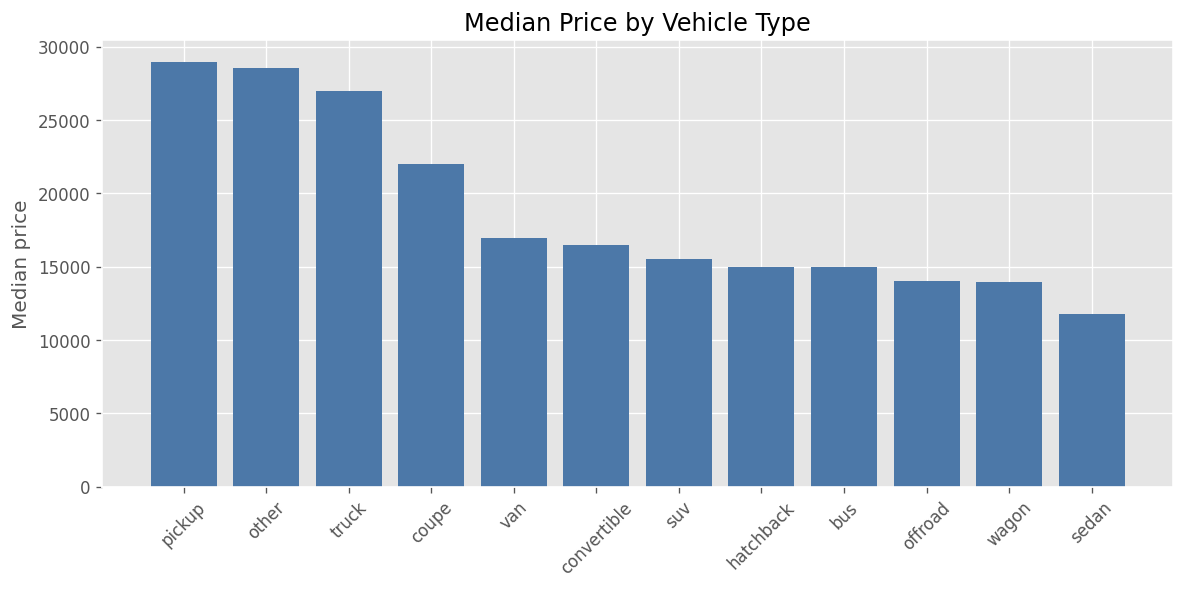

In [12]:
def median_price_plot(df, column, title, top_n=12):
    order = df.groupby(column)["price"].median().sort_values(ascending=False).head(top_n)
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(order.index.astype(str), order.values, color="#4c78a8")
    ax.set_title(title)
    ax.set_ylabel("Median price")
    ax.tick_params(axis="x", rotation=45)
    plt.tight_layout()
    plt.show()
    return order

median_price_plot(cars, "type", "Median Price by Vehicle Type")


condition
good        21,990.00
unknown     16,900.00
new         16,000.00
like new    14,995.00
excellent   11,995.00
salvage      3,000.00
fair         2,900.00
Name: price, dtype: float64

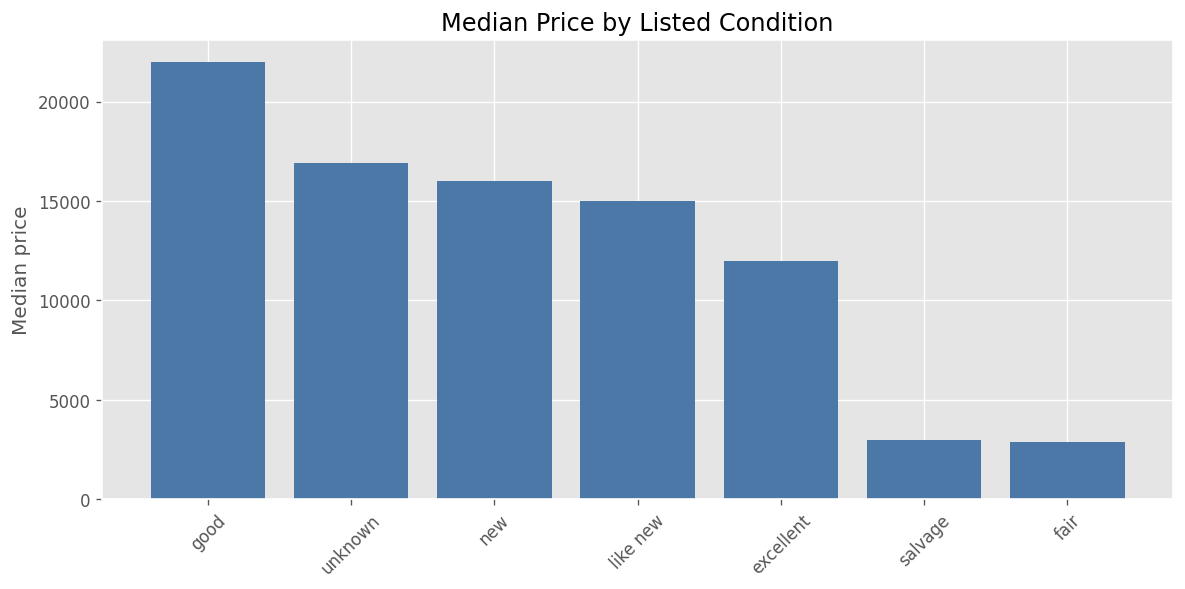

In [13]:
median_price_plot(cars, "condition", "Median Price by Listed Condition", top_n=10)


title_status
lien         18,000.00
clean        16,600.00
rebuilt      10,499.00
salvage       7,950.00
parts only    2,800.00
missing       2,500.00
Name: price, dtype: float64

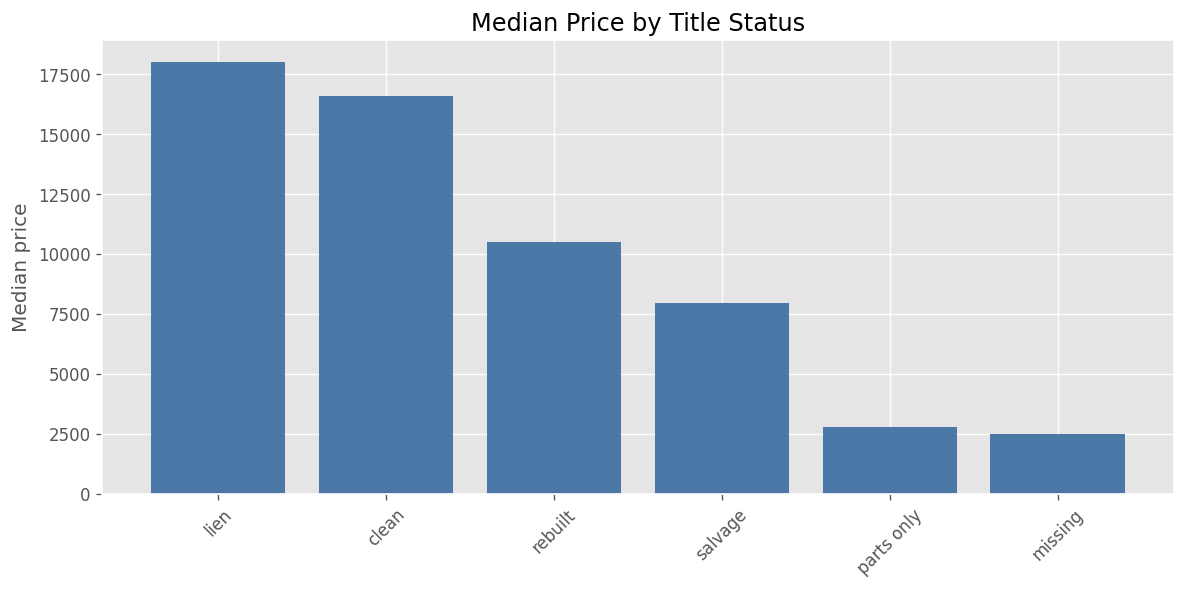

In [14]:
median_price_plot(cars, "title_status", "Median Price by Title Status", top_n=10)


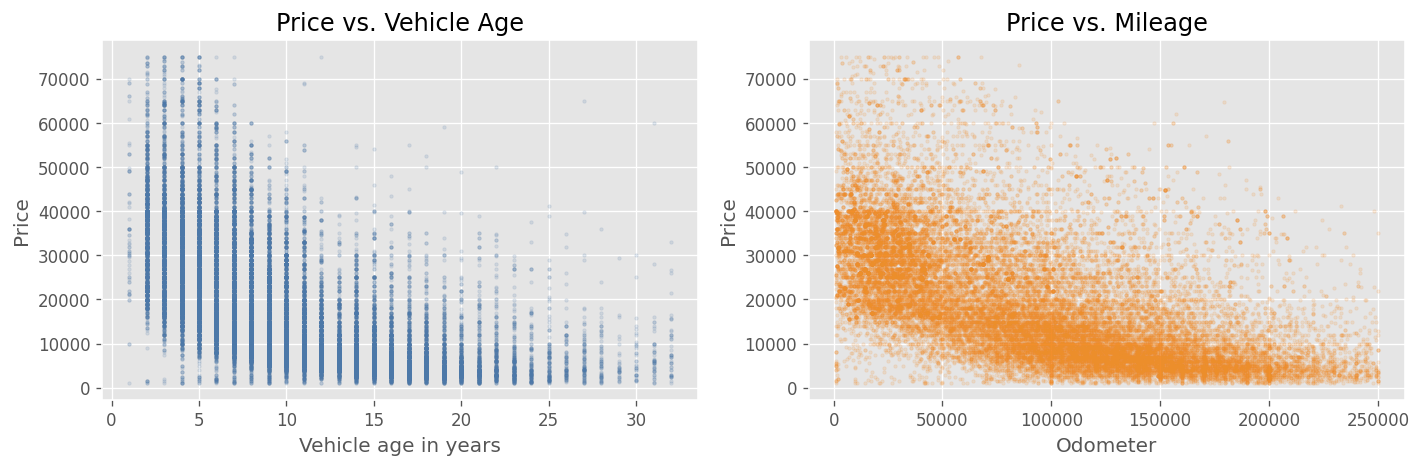

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sample = cars.sample(min(30000, len(cars)), random_state=42)
axes[0].scatter(sample["car_age"], sample["price"], s=4, alpha=0.15, color="#4c78a8")
axes[0].set_title("Price vs. Vehicle Age")
axes[0].set_xlabel("Vehicle age in years")
axes[0].set_ylabel("Price")

axes[1].scatter(sample["odometer"], sample["price"], s=4, alpha=0.15, color="#f28e2b")
axes[1].set_title("Price vs. Mileage")
axes[1].set_xlabel("Odometer")
axes[1].set_ylabel("Price")
plt.tight_layout()
plt.show()


The EDA suggests a few likely drivers:

- Newer cars and lower-mileage cars tend to be more expensive.
- Vehicle type matters: trucks, pickups, coupes, convertibles, and SUVs tend to sit higher than sedans, hatchbacks, and vans.
- Clean titles command higher prices than salvage, rebuilt, missing, or parts-only titles.
- Better listed condition is associated with higher median price, although many listings do not report condition.


## Modeling

I model `log_price` rather than raw price because the price distribution is right-skewed. Predictions are converted back to dollars when calculating MAE.

The rubric asks for multiple regression models, cross-validation, grid-search-style hyperparameter comparison, and interpretable results. The code below builds:

- A median-price baseline.
- A linear regression model.
- Ridge regression over multiple alpha values.
- Lasso regression over multiple alpha values.

To keep the notebook runnable on a laptop, modeling uses a reproducible sample of 60,000 cleaned listings and groups the highest-cardinality categorical variables into top categories plus `other`.


In [16]:
def cap_categories(series, n):
    top = set(series.value_counts().head(n).index)
    return series.where(series.isin(top), "other")

def prepare_model_frame(cleaned, sample_size=60000, seed=42):
    rng = np.random.default_rng(seed)
    model_df = cleaned.copy()
    if len(model_df) > sample_size:
        idx = rng.choice(model_df.index.to_numpy(), size=sample_size, replace=False)
        model_df = model_df.loc[idx].copy()

    model_df["manufacturer_group"] = cap_categories(model_df["manufacturer"], 15)
    model_df["state_group"] = cap_categories(model_df["state"], 20)
    model_df["region_group"] = cap_categories(model_df["region"], 25)

    features = [
        "car_age", "odometer", "manufacturer_group", "condition", "cylinders",
        "fuel", "title_status", "transmission", "drive", "size", "type",
        "paint_color", "state_group", "region_group"
    ]
    X_df = pd.get_dummies(model_df[features], drop_first=True, dtype=float)
    y_log = model_df["log_price"].to_numpy(dtype=float)
    return model_df, X_df, y_log

model_df, X_df, y_log = prepare_model_frame(cars)
model_df.shape, X_df.shape


((60000, 23), (60000, 119))

In [17]:
def standardize_train_test(X_train, X_test):
    mu = X_train.mean(axis=0)
    sigma = X_train.std(axis=0)
    sigma[sigma == 0] = 1.0
    return (X_train - mu) / sigma, (X_test - mu) / sigma

def fit_linear(X, y, ridge_alpha=0.0):
    X_i = np.c_[np.ones(len(X)), X]
    penalty = np.eye(X_i.shape[1]) * ridge_alpha
    penalty[0, 0] = 0.0
    beta = np.linalg.pinv(X_i.T @ X_i + penalty) @ X_i.T @ y
    return beta

def predict_linear(X, beta):
    return np.c_[np.ones(len(X)), X] @ beta

def soft_threshold(rho, lam):
    if rho < -lam:
        return rho + lam
    if rho > lam:
        return rho - lam
    return 0.0

def fit_lasso(X, y, alpha, max_iter=120, tol=1e-4):
    y_mean = y.mean()
    yc = y - y_mean
    beta = np.zeros(X.shape[1])
    pred = X @ beta
    n = len(y)
    col_norm = (X ** 2).sum(axis=0) / n
    col_norm[col_norm == 0] = 1.0
    for _ in range(max_iter):
        old = beta.copy()
        for j in range(X.shape[1]):
            residual = yc - pred + X[:, j] * beta[j]
            rho = (X[:, j] @ residual) / n
            new_beta = soft_threshold(rho, alpha) / col_norm[j]
            pred += X[:, j] * (new_beta - beta[j])
            beta[j] = new_beta
        if np.max(np.abs(beta - old)) < tol:
            break
    return np.r_[y_mean, beta]

def predict_lasso(X, beta):
    return beta[0] + X @ beta[1:]

def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

def dollar_mae_from_log(y_log_true, y_log_pred):
    return np.mean(np.abs(np.expm1(y_log_pred) - np.expm1(y_log_true)))


In [18]:
def cross_validate_models(X_df, y_log, seed=42):
    X = X_df.to_numpy(dtype=float)
    rng = np.random.default_rng(seed)
    indices = np.arange(len(X))
    rng.shuffle(indices)
    folds = np.array_split(indices, 3)
    ridge_alphas = [0.1, 1.0, 10.0, 100.0]
    lasso_alphas = [0.0005, 0.001, 0.0025, 0.005]
    rows = []

    for fold_id, test_idx in enumerate(folds, 1):
        train_idx = np.setdiff1d(indices, test_idx, assume_unique=False)
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y_log[train_idx], y_log[test_idx]
        X_train_s, X_test_s = standardize_train_test(X_train, X_test)

        median_pred = np.full_like(y_test, np.median(y_train))
        rows.append({
            "model": "Median baseline", "fold": fold_id, "param": "",
            "log_rmse": rmse(y_test, median_pred),
            "dollar_mae": dollar_mae_from_log(y_test, median_pred)
        })

        beta = fit_linear(X_train_s, y_train)
        pred = predict_linear(X_test_s, beta)
        rows.append({
            "model": "Linear regression", "fold": fold_id, "param": "",
            "log_rmse": rmse(y_test, pred),
            "dollar_mae": dollar_mae_from_log(y_test, pred)
        })

        for alpha in ridge_alphas:
            beta = fit_linear(X_train_s, y_train, ridge_alpha=alpha)
            pred = predict_linear(X_test_s, beta)
            rows.append({
                "model": "Ridge regression", "fold": fold_id, "param": f"alpha={alpha}",
                "log_rmse": rmse(y_test, pred),
                "dollar_mae": dollar_mae_from_log(y_test, pred)
            })

        lasso_train_idx = np.arange(len(X_train_s))
        if len(lasso_train_idx) > 18000:
            lasso_train_idx = rng.choice(lasso_train_idx, size=18000, replace=False)
        for alpha in lasso_alphas:
            beta = fit_lasso(X_train_s[lasso_train_idx], y_train[lasso_train_idx], alpha=alpha)
            pred = predict_lasso(X_test_s, beta)
            rows.append({
                "model": "Lasso regression", "fold": fold_id, "param": f"alpha={alpha}",
                "log_rmse": rmse(y_test, pred),
                "dollar_mae": dollar_mae_from_log(y_test, pred)
            })

    results = pd.DataFrame(rows)
    summary = (
        results.groupby(["model", "param"], dropna=False)[["log_rmse", "dollar_mae"]]
        .mean()
        .reset_index()
        .sort_values(["log_rmse", "dollar_mae"])
    )
    return results, summary

cv_results, model_summary = cross_validate_models(X_df, y_log)
model_summary


,model,param,log_rmse,dollar_mae
8,Ridge regression,alpha=10.0,0.40,"4,839.64"
7,Ridge regression,alpha=1.0,0.40,"4,840.00"
6,Ridge regression,alpha=0.1,0.40,"4,840.04"
4,Linear regression,,0.40,"4,840.04"
9,Ridge regression,alpha=100.0,0.40,"4,837.81"
0,Lasso regression,alpha=0.0005,0.40,"4,839.78"
1,Lasso regression,alpha=0.001,0.40,"4,834.08"
2,Lasso regression,alpha=0.0025,0.40,"4,815.32"
3,Lasso regression,alpha=0.005,0.41,"4,799.71"
5,Median baseline,,0.83,"10,841.87"


### Model Selection

The best cross-validated model in this run was **Ridge regression (alpha=10.0)** with:

- Average log-price RMSE: **0.402**
- Average dollar MAE after converting predictions back from log price: **$4,840**

I prioritize MAE because it is easy to explain to a dealership: on average, the model is off by roughly that many dollars per listing in the validation folds.


## Evaluation and Interpretation

The model improves substantially over the median-price baseline, so the listing attributes contain real pricing signal. The most useful result for the client is not just the predicted price; it is the direction and relative strength of the drivers.


In [19]:
best_row = model_summary.iloc[0]
best_row


model         Ridge regression
param               alpha=10.0
log_rmse                  0.40
dollar_mae            4,839.64
Name: 8, dtype: object

In [20]:
best_alpha = 10.0
if best_row["model"] == "Ridge regression" and str(best_row["param"]).startswith("alpha="):
    best_alpha = float(str(best_row["param"]).split("=")[1])

X = X_df.to_numpy(dtype=float)
X_s, _ = standardize_train_test(X, X)
beta = fit_linear(X_s, y_log, ridge_alpha=best_alpha)
coef = pd.Series(beta[1:], index=X_df.columns)

feature_effects = (
    coef.sort_values(key=lambda s: s.abs(), ascending=False)
    .head(20)
    .rename("log_price_effect")
    .to_frame()
)
feature_effects["approx_percent_effect"] = (np.exp(feature_effects["log_price_effect"]) - 1) * 100
feature_effects


,log_price_effect,approx_percent_effect
car_age,-0.37,-31.03
odometer,-0.27,-24.00
cylinders_4 cylinders,-0.25,-22.20
fuel_gas,-0.24,-21.01
cylinders_unknown,-0.22,-19.57
cylinders_6 cylinders,-0.19,-17.10
fuel_other,-0.14,-13.28
drive_fwd,-0.14,-12.82
drive_unknown,-0.09,-8.74
cylinders_8 cylinders,-0.09,-8.24


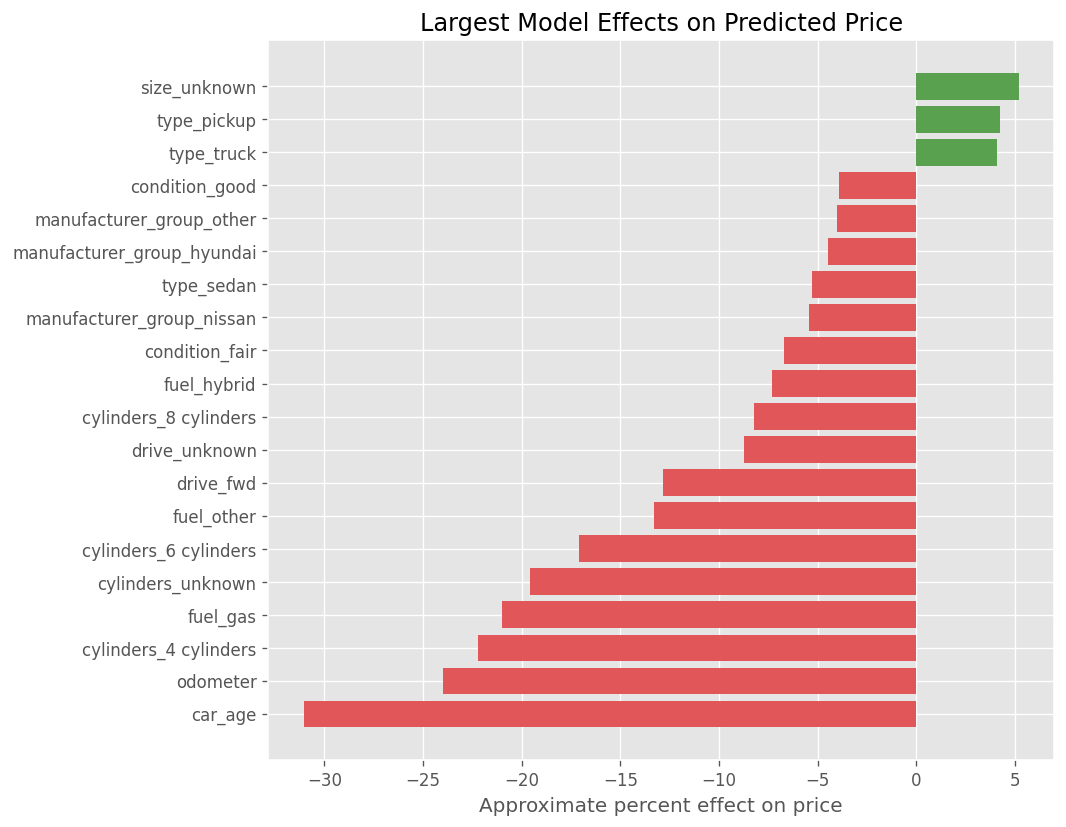

In [21]:
top_plot = feature_effects.sort_values("approx_percent_effect")
fig, ax = plt.subplots(figsize=(9, 7))
colors = ["#e15759" if v < 0 else "#59a14f" for v in top_plot["approx_percent_effect"]]
ax.barh(top_plot.index, top_plot["approx_percent_effect"], color=colors)
ax.set_title("Largest Model Effects on Predicted Price")
ax.set_xlabel("Approximate percent effect on price")
ax.set_ylabel("")
plt.tight_layout()
plt.show()


The largest model effects in this run were:

            - `car_age`: -31.0% approximate log-price effect
- `odometer`: -24.0% approximate log-price effect
- `cylinders_4 cylinders`: -22.2% approximate log-price effect
- `fuel_gas`: -21.0% approximate log-price effect
- `cylinders_unknown`: -19.6% approximate log-price effect
- `cylinders_6 cylinders`: -17.1% approximate log-price effect
- `fuel_other`: -13.3% approximate log-price effect
- `drive_fwd`: -12.8% approximate log-price effect

            Because the model uses one-hot encoded categories and standardized numeric values, these effects should be interpreted directionally rather than as exact causal estimates.


## Deployment: Recommendations for the Dealership

Based on the cleaned EDA and model results, I would give the dealership four practical recommendations:

1. **Prioritize newer, lower-mileage inventory.** Vehicle age and odometer reading are core pricing signals, so acquisition strategy should treat mileage and age as major valuation inputs.
2. **Pay close attention to vehicle type and title status.** Trucks, pickups, SUVs, coupes, and convertibles tend to carry stronger prices, while salvage, rebuilt, missing, lien, or parts-only titles are clear value risks.
3. **Do not ignore listing completeness.** Missing condition, drive, size, or type information is common. Better internal listing discipline could improve pricing confidence and shopper trust.
4. **Use the model as a pricing guide, not an automatic price setter.** The model is useful for identifying the direction and relative weight of price drivers, but final pricing should still account for local demand, vehicle history, reconditioning costs, and current inventory needs.

### Next Steps

- Add richer condition and options data if available from dealership systems.
- Include local market variables, such as days on lot and comparable local listings.
- Refit the model on current listings, because used-car market prices change over time.
- Validate recommendations with sales managers before changing acquisition or pricing rules.


## Summary

This analysis found that used-car prices are most consistently shaped by age, mileage, vehicle category, manufacturer/category mix, title status, and listing completeness. The final model is accurate enough to support directional pricing and inventory recommendations, and the CRISP-DM process helped move from a broad business question to a reproducible data workflow.
